In [80]:
%load_ext autoreload
%autoreload 2
import numpy as np
import uproot
import awkward as ak
import matplotlib.pyplot as plt
from coffea import util
from coffea.processor import accumulate
import os
import re
import pandas as pd
import hist
import matplotlib as mpl
import mplhep
import sys

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [81]:
file10 = uproot.open("AODSkimmer/corrected_signal_2022_files/HighEvents/final/Signal_Mchi-10p5_dMchi-1p0_ctau-10_output.root")
file20 = uproot.open("AODSkimmer/corrected_signal_2022_files/HighEvents/final/Signal_Mchi-31p5_dMchi-3p0_ctau-10_output.root")
file30 = uproot.open("AODSkimmer/corrected_signal_2022_files/HighEvents/final/Signal_Mchi-52p5_dMchi-5p0_ctau-10_output.root")

dir10= file10["ntuples"]    
tree10 = dir10["outT"]

dir20= file20["ntuples"]    
tree20 = dir20["outT"]

dir30= file30["ntuples"]    
tree30 = dir30["outT"]

In [82]:
pdgs10 = tree10["GenPart_ID"].array()
mask10 = pdgs10==1000023

pdgs20 = tree20["GenPart_ID"].array()
mask20 = pdgs20==1000023

pdgs30 = tree30["GenPart_ID"].array()
mask30 = pdgs30==1000023

energychi210: [[226], [1.44e+03], [121], [898], [632], ... [188], [1.93e+03], [74.1], [257], [126]]
energychi220: [[411], [35.6], [294], [38.1], [44.3], ... [396], [91.1], [137], [44.7], [147]]
energychi250: [[263], [347], [233], [1.4e+03], [516], ... [146], [523], [611], [629], [138]]


Text(0.5, 0, 'Energy of chi2 (in GeV)')

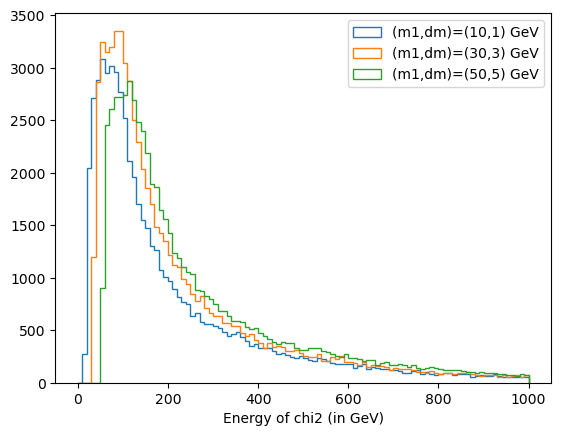

In [83]:
#Gamma calculation
energy10 = tree10["GenPart_e"].array()
energychi210=energy10[mask10]
print ("energychi210:", energychi210)

energy20 = tree20["GenPart_e"].array()
energychi220=energy20[mask20]

energy30 = tree30["GenPart_e"].array()
energychi230=energy30[mask30]

print ("energychi220:", energychi220)
print ("energychi250:", energychi230)

plt.hist(energychi210, range=(0,1000),bins=100, histtype="step", label="(m1,dm)=(10,1) GeV")
plt.hist(energychi220, range=(0,1000),bins=100, histtype="step", label="(m1,dm)=(30,3) GeV")
plt.hist(energychi230, range=(0,1000),bins=100, histtype="step", label="(m1,dm)=(50,5) GeV")

plt.legend()
plt.xlabel("Energy of chi2 (in GeV)")
# plt.savefig("Echi2.png", dpi=300)

Text(0.5, 0, 'Mass of chi2 (in GeV)')

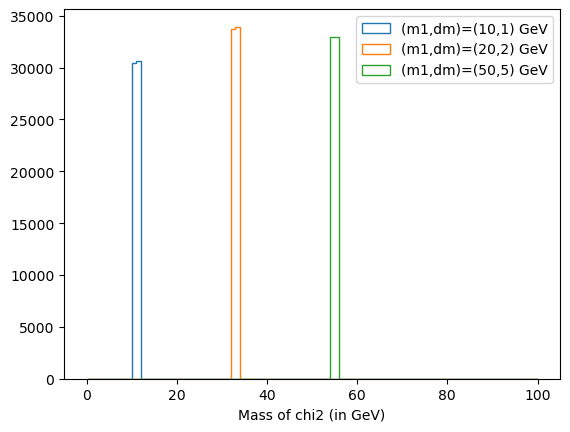

In [84]:
mass10 = tree10["GenPart_mass"].array()
mchi210 = mass10[mask10]

mass20 = tree20["GenPart_mass"].array()
mchi220 = mass20[mask20]

mass30 = tree30["GenPart_mass"].array()
mchi230 = mass30[mask30]

plt.hist(mchi210, range=(0,100),bins=100, histtype="step", label="(m1,dm)=(10,1) GeV")
plt.hist(mchi220, range=(0,100),bins=100, histtype="step", label="(m1,dm)=(20,2) GeV")
plt.hist(mchi230, range=(0,100),bins=100, histtype="step", label="(m1,dm)=(50,5) GeV")

plt.legend()
plt.xlabel("Mass of chi2 (in GeV)")


Text(0.5, 0, 'Gamma')

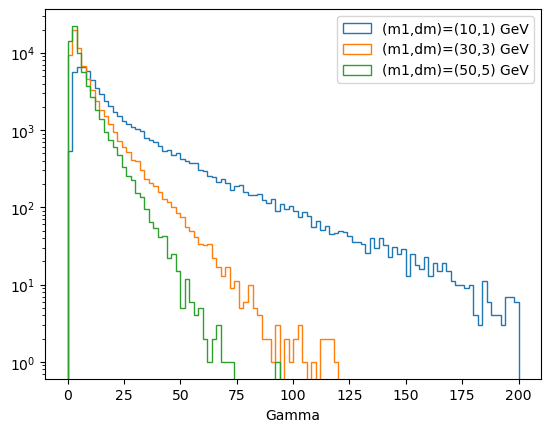

In [103]:
gamma10= energychi210/mchi210
gamma20= energychi220/mchi220
gamma30= energychi230/mchi230


plt.hist(gamma10, range=(0,200),bins=100, log=True, histtype="step", label="(m1,dm)=(10,1) GeV")
plt.hist(gamma20, range=(0,200),bins=100,log=True, histtype="step", label="(m1,dm)=(30,3) GeV")
plt.hist(gamma30, range=(0,200),bins=100, log=True, histtype="step", label="(m1,dm)=(50,5) GeV")

plt.legend()
plt.xlabel("Gamma")

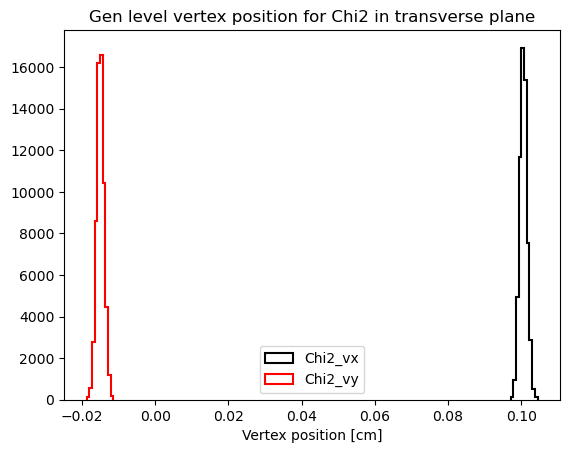

In [86]:
vx_chi2 = ak.flatten(tree10['GenPart_vx'].array()[mask10])
vy_chi2 = ak.flatten(tree10['GenPart_vy'].array()[mask10])
vz_chi2 = ak.flatten(tree10['GenPart_vz'].array()[mask10])


plt.hist(vx_chi2,histtype="step",color = 'black', linewidth=1.5, label="Chi2_vx")
plt.hist(vy_chi2,histtype="step",color = 'red', linewidth=1.5, label="Chi2_vy")

plt.xlabel("Vertex position [cm]")
plt.legend()
plt.title("Gen level vertex position for Chi2 in transverse plane")
plt.show()

Text(0.5, 0, 'Chi2_vz [cm]')

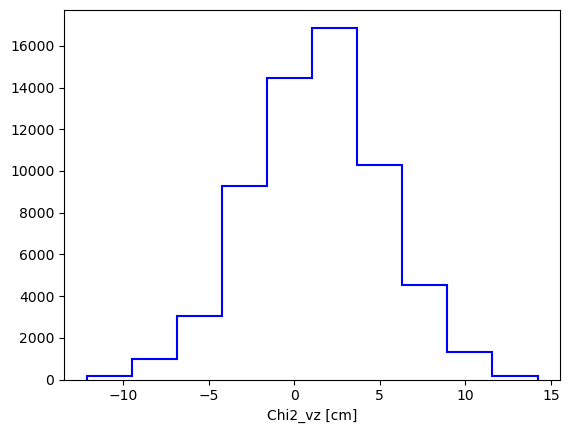

In [87]:
plt.hist(vz_chi2,histtype="step",color = 'blue', linewidth=1.5)
plt.xlabel("Chi2_vz [cm]")

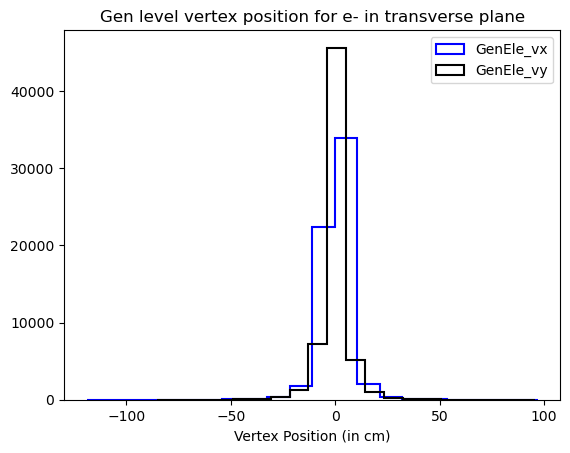

In [88]:
vx_genele = tree10['GenEle_vx'].array() 
vy_genele = tree10['GenEle_vy'].array() 
vz_genele = tree10['GenEle_vz'].array() 

plt.hist(vx_genele,histtype="step",color = 'blue', bins=20, linewidth=1.5, label="GenEle_vx")
plt.hist(vy_genele,histtype="step",color = 'black', bins=20, linewidth=1.5, label="GenEle_vy")

plt.xlabel("Vertex Position (in cm)")
plt.title("Gen level vertex position for e- in transverse plane")
plt.legend()
plt.show()

Text(0.5, 0, 'gen_vz [cm]')

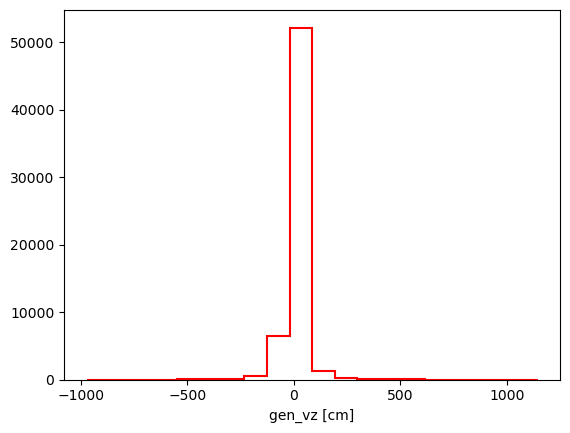

In [89]:
plt.hist(vz_genele,histtype="step",color = 'red', bins=20, linewidth=1.5, label="GenEle_vz")
plt.xlabel("gen_vz [cm]")

In [90]:
decaylength_chi2 = np.sqrt( (vx_genele-vx_chi2)**2 + (vy_genele-vy_chi2)**2 + (vz_genele-vz_chi2)**2 )  #in cm
print (decaylength_chi2)

[1.85, 62.3, 2.6, 18.8, 32.4, 9.97, 1.1, ... 3.79, 9.91, 7.08, 211, 7.99, 6.25, 7.14]


In [91]:
# gamma= energychi2/mchi2
# decaylength_chi2 = np.sqrt( (vx_genele-vx_chi2)**2 + (vy_genele-vy_chi2)**2 + (vz_genele-vz_chi2)**2 )  #in cm
# ctau=decaylength_chi2/gamma

In [92]:
ctau=decaylength_chi2/gamma10

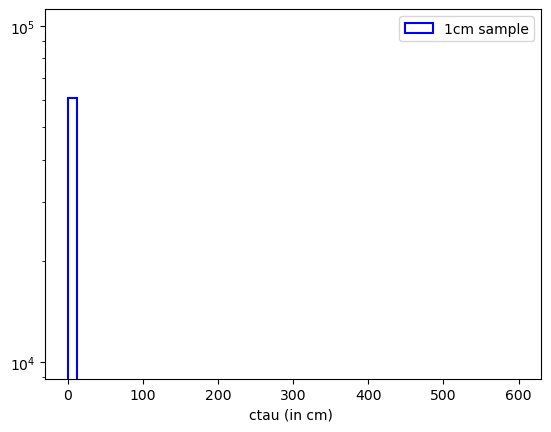

In [93]:
plt.hist(ctau,histtype="step",color = 'blue',linewidth=1.5, range=(0,600),bins=50, log=True, label="1cm sample")
plt.xlabel("ctau (in cm) ")
plt.legend()
plt.savefig("ctau10", dpi=300)

[6.1076e+04 2.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00
 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00
 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00
 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00
 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00
 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00
 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00
 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00
 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00
 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00]
[6.1076e+04 2.0000e+00]
2
2


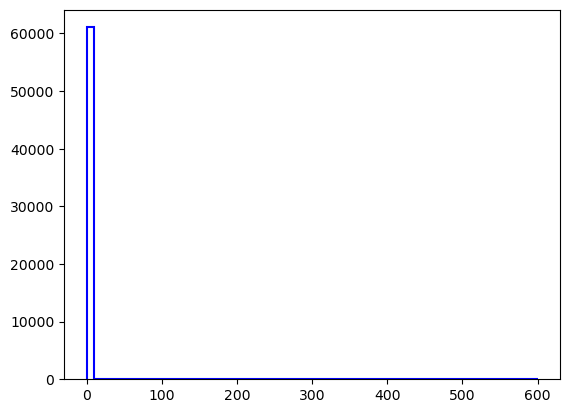

In [94]:
#Fitting part
y,x, _= plt.hist(ctau,histtype="step",color = 'blue',linewidth=1.5, range=(0,600),bins=60)

print (y)

mask = y>0
ym = y[mask]
print (ym)

y_fit = np.log(y[mask]) #y for fit
print (len(y_fit))
ct= (x[:-1] + x[1:])/2   #the ct values (in cm)
x_fit=ct[mask]  #x for fit

sigma = 1/(np.sqrt(ym)) #sigma for fit
print (len(sigma))

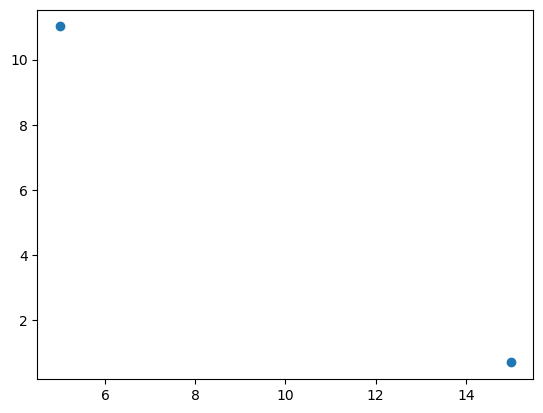

In [95]:
plt.scatter(x_fit, y_fit)

In [96]:
def linear(x_fit,m,b):
    return (m*(x_fit)+b)

from scipy.optimize import curve_fit

params, cov = curve_fit(linear,x_fit,y_fit, sigma=sigma)
m_fit, b_fit = params

ctau0 = -1/m_fit

print ("Fitted b =", b_fit) 
print("Fitted m =", m_fit)  
print("ctau0 =", ctau0)

Fitted b = 16.18323781367513
Fitted m = -1.0326727088743457
ctau0 = 0.9683610222352441


/uscms/home/reshmar/nobackup/miniforge3/envs/coffea/lib/python3.8/site-packages/scipy/optimize/_minpack_py.py:906: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',


In [97]:
#For goodness of fit:
residuals = y_fit - linear(x_fit, m_fit, b_fit)

chi2 = np.sum((residuals / sigma)**2)

ndof = len(y_fit) - len(params)   # N - number of fit parameters
chi2_red = chi2 / ndof

print("chi2 =", chi2)
print("ndof =", ndof)
print("chi2/ndof =", chi2_red)

chi2 = 2.4651903288156624e-32
ndof = 0
chi2/ndof = inf


/tmp/ipykernel_2539527/2663849895.py:7: RuntimeWarning: divide by zero encountered in scalar divide
  chi2_red = chi2 / ndof


/tmp/ipykernel_2539527/4082479194.py:3: RuntimeWarning: divide by zero encountered in scalar divide
  label=f"Fit: ctau0 = {ctau0:.2f} cm , chi2/ndof = {chi2/ndof:.2f}")


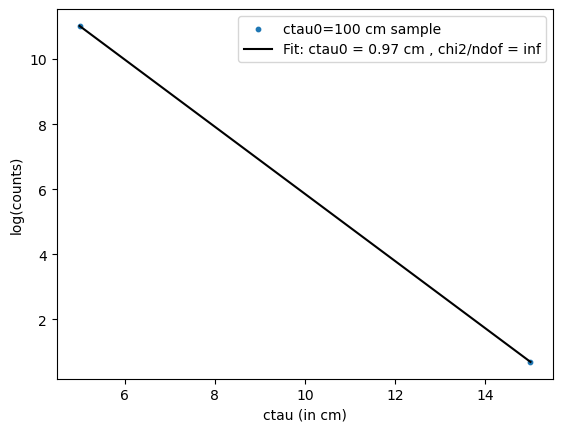

<Figure size 640x480 with 0 Axes>

In [98]:
plt.scatter(x_fit, y_fit, s=10, label="ctau0=100 cm sample")
plt.plot(x_fit, linear(x_fit, m_fit, b_fit),color='black',
         label=f"Fit: ctau0 = {ctau0:.2f} cm , chi2/ndof = {chi2/ndof:.2f}")



# plt.plot(x_fit, linear(x_fit, m, c), color="red",
#          label=f"fit: ctau0 = {ctau0:.1f}")
plt.xlabel("ctau (in cm)")
plt.ylabel("log(counts)")
plt.legend()
plt.show()

plt.savefig("ctauFIT1cm1000mm.png", dpi=300)